In [55]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from config import settings
from data import SQLRepository, AlphaVantageAPI
from model import GarchModel
import requests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [6]:
url = (
    "https://www.alphavantage.co/query?"
    "function=TIME_SERIES_DAILY"
    "symbol=AMBUJACEM.BSE&"
    f"apikey={settings.alpha_api_key}"
)

print("url type:", type(url))
url

url type: <class 'str'>


'https://www.alphavantage.co/query?function=TIME_SERIES_DAILYsymbol=AMBUJACEM.BSE&apikey=8912bf183f72eb017b550663ba8241203d958acddd135b8b671907e41fb1c482a117e94d0638b4d0fab752977ac1cb43de0c5c2a3b818f9b527ab75dbc04752c7339396231d03a76e4393ad59a37d704c2cbb92ffa453e95a48e9749a04977edeec75ca500ceded15cd4e0f6a5fdd5dd1f38a1806b6bf68cec9ec6e73b5aa35d'

In [20]:
ticker = "AMBUJACEM.BSE"
output_size = "full"
data_type = "json"


url = (
    "https://learn-api.wqu.edu/1/data-services/alpha-vantage/query?"
    "function=TIME_SERIES_DAILY&"
    f"symbol={ticker}&"
    f"outputsize={output_size}&"
    f"datatype={data_type}&"
    f"apikey={settings.alpha_api_key}"
)

print("url type:", type(url))
url

url type: <class 'str'>


'https://learn-api.wqu.edu/1/data-services/alpha-vantage/query?function=TIME_SERIES_DAILY&symbol=AMBUJACEM.BSE&outputsize=full&datatype=json&apikey=8912bf183f72eb017b550663ba8241203d958acddd135b8b671907e41fb1c482a117e94d0638b4d0fab752977ac1cb43de0c5c2a3b818f9b527ab75dbc04752c7339396231d03a76e4393ad59a37d704c2cbb92ffa453e95a48e9749a04977edeec75ca500ceded15cd4e0f6a5fdd5dd1f38a1806b6bf68cec9ec6e73b5aa35d'

In [21]:
response = requests.get(url=url)

response_data = response.json()

print("response_data type:", type(response_data))
print("response type:", type(response))

response_data type: <class 'dict'>
response type: <class 'requests.models.Response'>


In [11]:
response_data

{'Meta Data': {'1. Information': 'Daily Prices (open, high, low, close) and Volumes',
  '2. Symbol': 'AMBUJACEM.BSE',
  '3. Last Refreshed': '2026-04-08',
  '4. Output Size': 'Compact',
  '5. Time Zone': 'US/Eastern'},
 'Time Series (Daily)': {'2026-04-08': {'1. open': '436.8500',
   '2. high': '462.2500',
   '3. low': '436.7000',
   '4. close': '446.6500',
   '5. volume': '251147'},
  '2026-04-07': {'1. open': '429.3500',
   '2. high': '429.3500',
   '3. low': '418.1000',
   '4. close': '420.2500',
   '5. volume': '118184'},
  '2026-04-06': {'1. open': '421.3500',
   '2. high': '431.4500',
   '3. low': '412.5000',
   '4. close': '430.1000',
   '5. volume': '73890'},
  '2026-04-02': {'1. open': '416.4500',
   '2. high': '420.0000',
   '3. low': '407.0000',
   '4. close': '418.3000',
   '5. volume': '74593'},
  '2026-04-01': {'1. open': '418.5000',
   '2. high': '421.9000',
   '3. low': '409.4000',
   '4. close': '420.0500',
   '5. volume': '139885'},
  '2026-03-30': {'1. open': '406.05

In [22]:
stock_data = response_data["Time Series (Daily)"]
print("stock_data type:", type(stock_data))
stock_data

stock_data type: <class 'dict'>


{'2026-04-08': {'1. open': '436.8500',
  '2. high': '462.2500',
  '3. low': '436.7000',
  '4. close': '446.6500',
  '5. volume': '251147'},
 '2026-04-07': {'1. open': '429.3500',
  '2. high': '429.3500',
  '3. low': '418.1000',
  '4. close': '420.2500',
  '5. volume': '118184'},
 '2026-04-06': {'1. open': '421.3500',
  '2. high': '431.4500',
  '3. low': '412.5000',
  '4. close': '430.1000',
  '5. volume': '73890'},
 '2026-04-02': {'1. open': '416.4500',
  '2. high': '420.0000',
  '3. low': '407.0000',
  '4. close': '418.3000',
  '5. volume': '74593'},
 '2026-04-01': {'1. open': '418.5000',
  '2. high': '421.9000',
  '3. low': '409.4000',
  '4. close': '420.0500',
  '5. volume': '139885'},
 '2026-03-30': {'1. open': '406.0500',
  '2. high': '410.9500',
  '3. low': '399.5000',
  '4. close': '400.9000',
  '5. volume': '285375'},
 '2026-03-27': {'1. open': '418.5500',
  '2. high': '418.6000',
  '3. low': '408.0000',
  '4. close': '408.9500',
  '5. volume': '229442'},
 '2026-03-25': {'1. op

In [25]:
df_ambuja = pd.DataFrame.from_dict(stock_data, orient="index", dtype=float)

print("df_ambuja shape:", df_ambuja.shape)
print()
print(df_ambuja.info())
df_ambuja.head(10)

df_ambuja shape: (5235, 5)

<class 'pandas.DataFrame'>
Index: 5235 entries, 2026-04-08 to 2005-01-03
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   1. open    5235 non-null   float64
 1   2. high    5235 non-null   float64
 2   3. low     5235 non-null   float64
 3   4. close   5235 non-null   float64
 4   5. volume  5235 non-null   float64
dtypes: float64(5)
memory usage: 245.4+ KB
None


,1. open,2. high,3. low,4. close,5. volume
2026-04-08,436.85,462.25,436.70,446.65,251147.0
2026-04-07,429.35,429.35,418.10,420.25,118184.0
2026-04-06,421.35,431.45,412.50,430.10,73890.0
2026-04-02,416.45,420.00,407.00,418.30,74593.0
2026-04-01,418.50,421.90,409.40,420.05,139885.0
2026-03-30,406.05,410.95,399.50,400.90,285375.0
2026-03-27,418.55,418.60,408.00,408.95,229442.0
2026-03-25,411.20,427.75,411.20,422.10,285940.0
2026-03-24,408.15,413.40,395.25,407.55,200271.0
2026-03-23,416.75,416.85,394.00,395.40,359064.0


In [26]:
# Convert `df_ambuja` index to `DatetimeIndex`
df_ambuja.index = pd.to_datetime(df_ambuja.index)

# Name index "date"
df_ambuja.index.name = "date"

print(df_ambuja.info())
df_ambuja.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 5235 entries, 2026-04-08 to 2005-01-03
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   1. open    5235 non-null   float64
 1   2. high    5235 non-null   float64
 2   3. low     5235 non-null   float64
 3   4. close   5235 non-null   float64
 4   5. volume  5235 non-null   float64
dtypes: float64(5)
memory usage: 245.4 KB
None


,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2026-04-08,436.85,462.25,436.7,446.65,251147.0
2026-04-07,429.35,429.35,418.1,420.25,118184.0
2026-04-06,421.35,431.45,412.5,430.10,73890.0
2026-04-02,416.45,420.00,407.0,418.30,74593.0
2026-04-01,418.50,421.90,409.4,420.05,139885.0


In [27]:
# Remove numbering from `df_ambuja` column names
df_ambuja.columns = [c.split(" ")[1] for c in df_ambuja.columns]


print(df_ambuja.info())
df_ambuja.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 5235 entries, 2026-04-08 to 2005-01-03
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5235 non-null   float64
 1   high    5235 non-null   float64
 2   low     5235 non-null   float64
 3   close   5235 non-null   float64
 4   volume  5235 non-null   float64
dtypes: float64(5)
memory usage: 245.4 KB
None


,open,high,low,close,volume
date,,,,,
2026-04-08,436.85,462.25,436.7,446.65,251147.0
2026-04-07,429.35,429.35,418.1,420.25,118184.0
2026-04-06,421.35,431.45,412.5,430.10,73890.0
2026-04-02,416.45,420.00,407.0,418.30,74593.0
2026-04-01,418.50,421.90,409.4,420.05,139885.0


In [42]:
avi = AlphaVantageAPI()

df_ambuja = avi.get_daily("AMBUJACEM.BSE")
print(df_ambuja.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 5235 entries, 2026-04-08 to 2005-01-03
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5235 non-null   float64
 1   high    5235 non-null   float64
 2   low     5235 non-null   float64
 3   close   5235 non-null   float64
 4   volume  5235 non-null   float64
dtypes: float64(5)
memory usage: 245.4 KB
None


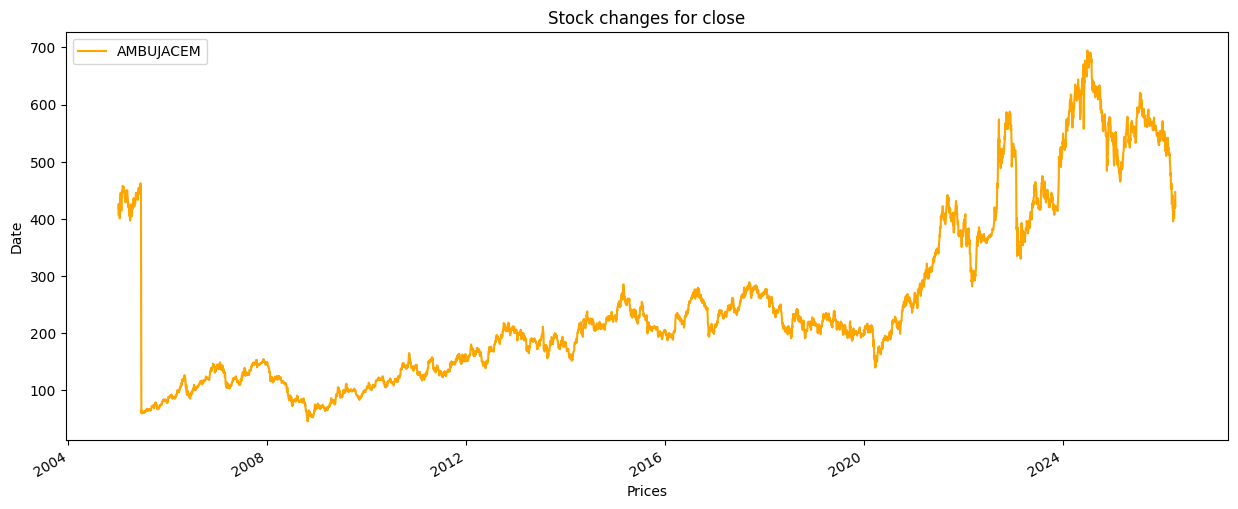

In [43]:
fig, ax = plt.subplots(figsize=(15, 6))
# Plot `df_ambuja` closing price
df_ambuja['close'].plot(ax=ax, label="AMBUJACEM", color="orange")

# Label axes
plt.xlabel("Prices")
plt.ylabel("Date")
plt.title("Stock changes for close")


# Add legend
plt.legend()

In [40]:
df_suzlon = avi.get_daily("SUZLON.BSE")

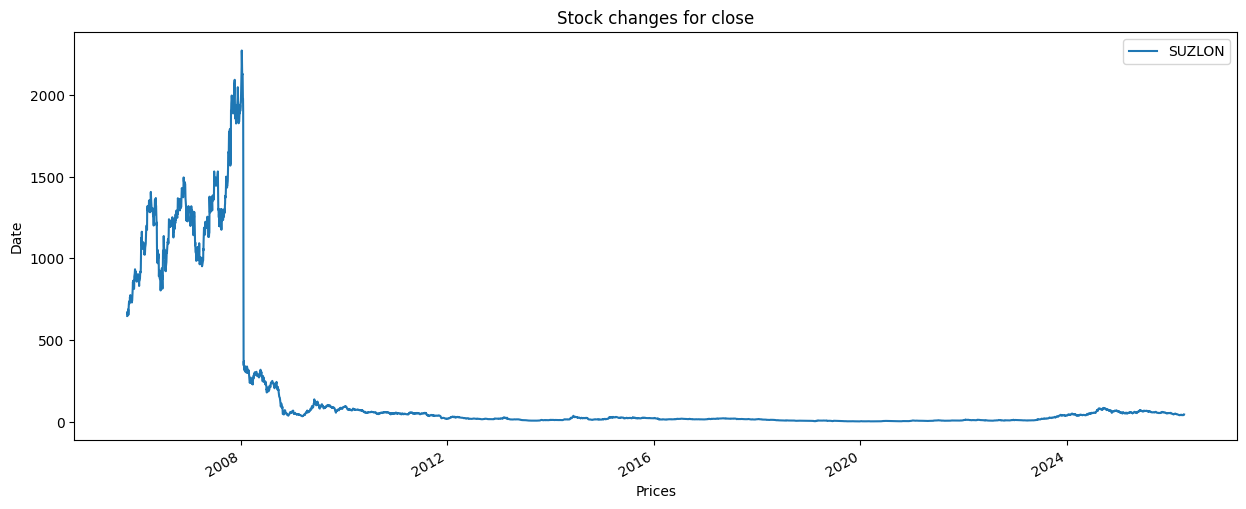

In [45]:
fig, ax = plt.subplots(figsize=(15, 6))
# Plot `df_suzlon` closing price
df_suzlon["close"].plot(ax=ax, label="SUZLON",)

# Label axes
plt.xlabel("Prices")
plt.ylabel("Date")
plt.title("Stock changes for close")


# Add legend
plt.legend()

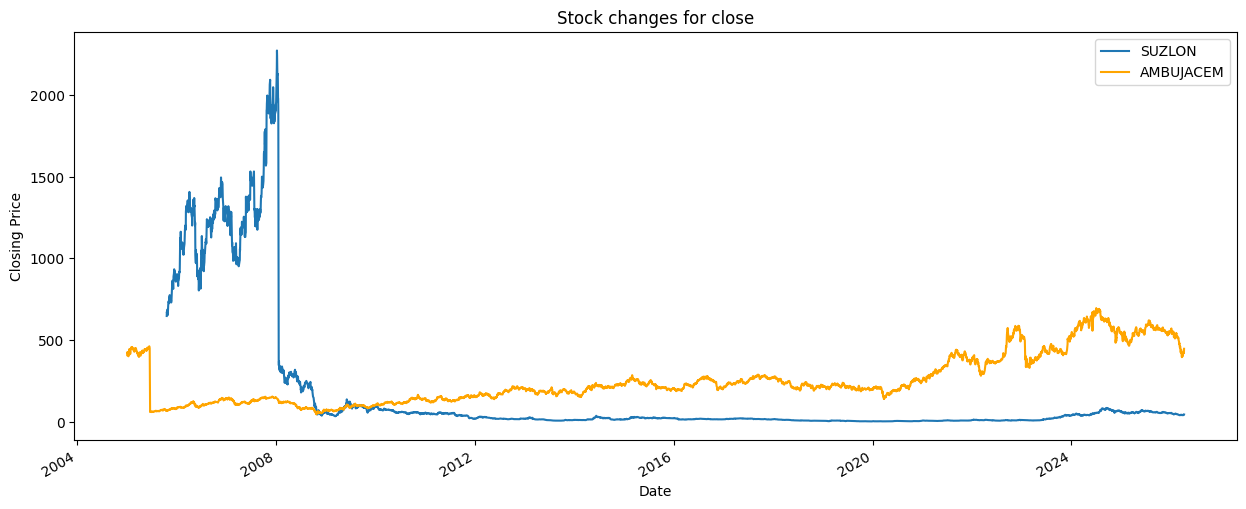

In [44]:
fig, ax = plt.subplots(figsize=(15, 6))
# Plot `df_suzlon` and `df_ambuja`
df_suzlon["close"].plot(ax=ax, label="SUZLON",)
df_ambuja["close"].plot(ax=ax, label="AMBUJACEM",  color="orange")

# Label axes

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Stock changes for close")


# Add legend
plt.legend()

In [46]:
# Sort DataFrame ascending by date
df_ambuja.sort_index(ascending=True, inplace=True)

# Create "return" column
df_ambuja['return'] = df_ambuja["close"].pct_change() * 100

print("df_ambuja shape:", df_ambuja.shape)
print(df_ambuja.info())
df_ambuja.head()

df_ambuja shape: (5235, 6)
<class 'pandas.DataFrame'>
DatetimeIndex: 5235 entries, 2005-01-03 to 2026-04-08
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5235 non-null   float64
 1   high    5235 non-null   float64
 2   low     5235 non-null   float64
 3   close   5235 non-null   float64
 4   volume  5235 non-null   float64
 5   return  5234 non-null   float64
dtypes: float64(6)
memory usage: 286.3 KB
None


,open,high,low,close,volume,return
date,,,,,,
2005-01-03,405.0001,409.5001,403.1001,407.6001,1061050.0,NaN
2005-01-04,410.0001,429.0001,409.0001,425.8501,2501549.0,4.477428
2005-01-05,427.0001,439.9001,406.1501,425.9501,3537669.0,0.023482
2005-01-06,426.0001,431.0001,412.0001,416.0501,3103853.0,-2.324216
2005-01-07,420.0001,428.5001,418.0001,426.3001,2330736.0,2.463646


In [60]:
# Sort DataFrame ascending by date
df_suzlon.sort_index(ascending=True, inplace=True)

# Create "return" column
df_suzlon['return'] = df_suzlon['close'].pct_change() * 100

print("df_suzlon shape:", df_suzlon.shape)
print(df_suzlon.info())
df_suzlon.head()

df_suzlon shape: (5042, 6)
<class 'pandas.DataFrame'>
DatetimeIndex: 5042 entries, 2005-10-20 to 2026-04-08
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5042 non-null   float64
 1   high    5042 non-null   float64
 2   low     5042 non-null   float64
 3   close   5042 non-null   float64
 4   volume  5042 non-null   float64
 5   return  5041 non-null   float64
dtypes: float64(6)
memory usage: 275.7 KB
None


,open,high,low,close,volume,return
date,,,,,,
2005-10-20,697.0003,709.8002,637.0002,647.4003,22683542.0,NaN
2005-10-21,644.4502,685.1003,637.0002,673.1503,14260538.0,3.977446
2005-10-24,683.0003,689.5502,648.0003,653.3503,7340714.0,-2.941394
2005-10-25,654.0003,663.9003,642.2503,659.0003,4034972.0,0.864773
2005-10-26,660.0003,693.4503,650.1003,687.9003,8950423.0,4.385430


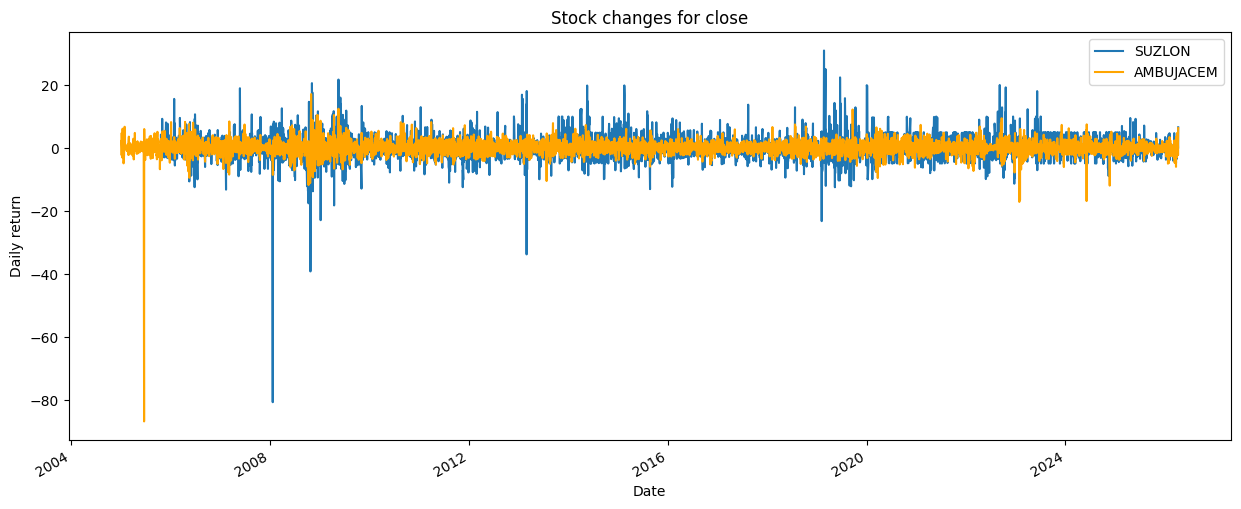

In [48]:
fig, ax = plt.subplots(figsize=(15, 6))
df_suzlon["return"].plot(ax=ax, label="SUZLON",)
df_ambuja["return"].plot(ax=ax, label="AMBUJACEM",  color="orange")

# Label axes

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.title("Stock changes for close")


# Add legend
plt.legend()

C:\Users\user\AppData\Local\Temp\ipykernel_81452\3721764573.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


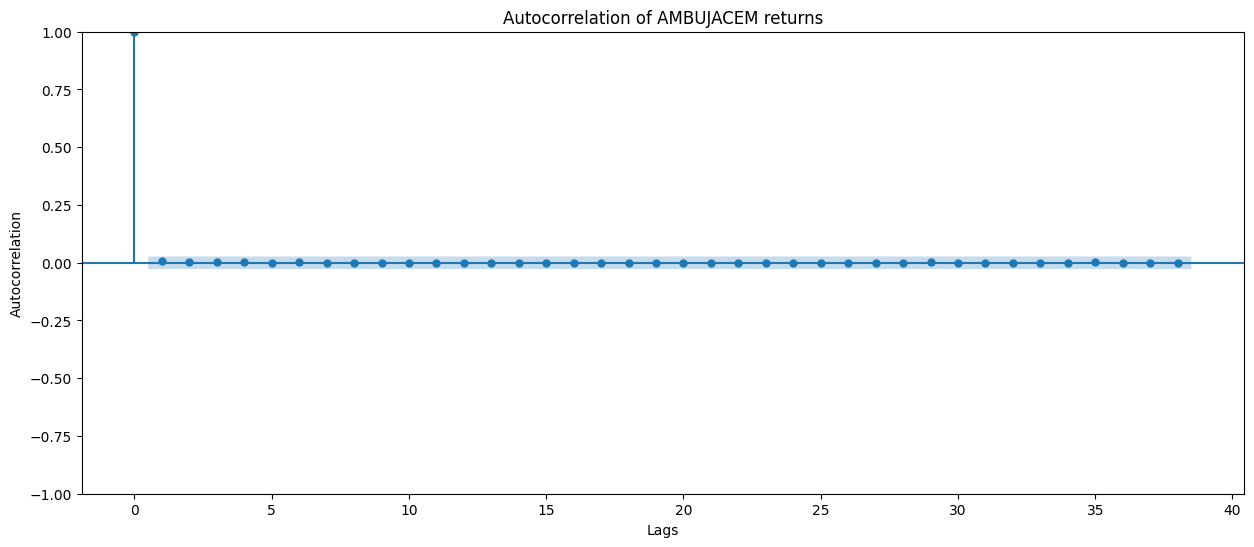

In [63]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_acf((df_ambuja["return"]**2).dropna(), ax=ax)

ax.set_xlabel("Lags")
ax.set_ylabel("Autocorrelation")

ax.set_title("Autocorrelation of AMBUJACEM returns")

fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_81452\2923698292.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


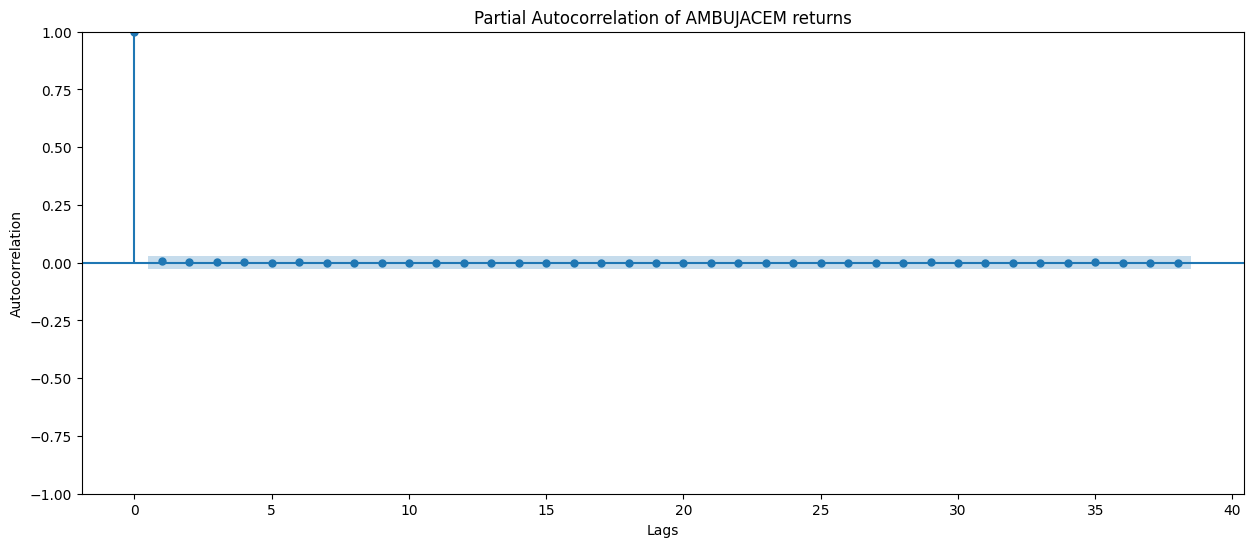

In [66]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_pacf((df_ambuja["return"]**2).dropna(), ax=ax)

ax.set_xlabel("Lags")
ax.set_ylabel("Autocorrelation")

ax.set_title("Partial Autocorrelation of AMBUJACEM returns")

fig.show()